In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
%matplotlib inline

from PIL import Image


In [ ]:
def load_image_into_numpy_array(path):
  """Load an image from file into a numpy array.

  Puts image into numpy array to feed into tensorflow graph.
  Note that by convention we put it into a numpy array with shape
  (height, width, channels), where channels=3 for RGB.

  Args:
    path: a file path (this can be local or on colossus)

  Returns:
    uint8 numpy array with shape (img_height, img_width, 3)
  """
  # img_data = tf.io.gfile.GFile(path, 'rb').read()
  # image = Image.open(BytesIO(img_data))
  image = Image.open(path)
  (im_width, im_height) = image.size

  if len(np.asarray(image).shape)<3:
    img_3d = np.expand_dims(image, -1) #last_axis = -1
    return np.repeat(img_3d, 3, 2).astype('uint8') # repeats=3, dim_to_repeat=2
  else:
    return np.array(image.getdata()).reshape((im_height, im_width, 3)).astype(np.uint8)

# Load the COCO Label Map
category_index = {
    1: {'id': 1, 'name': 'person'},
    2: {'id': 2, 'name': 'bicycle'},
    3: {'id': 3, 'name': 'car'},
    4: {'id': 4, 'name': 'motorcycle'},
    5: {'id': 5, 'name': 'airplane'},
    6: {'id': 6, 'name': 'bus'},
    7: {'id': 7, 'name': 'train'},
    8: {'id': 8, 'name': 'truck'},
    9: {'id': 9, 'name': 'boat'},
    10: {'id': 10, 'name': 'traffic_light'},
    11: {'id': 11, 'name': 'fire_hydrant'},
    13: {'id': 13, 'name': 'stop_sign'},
    14: {'id': 14, 'name': 'parking_meter'},
    15: {'id': 15, 'name': 'bench'},
    16: {'id': 16, 'name': 'bird'},
    17: {'id': 17, 'name': 'cat'},
    18: {'id': 18, 'name': 'dog'},
    19: {'id': 19, 'name': 'horse'},
    20: {'id': 20, 'name': 'sheep'},
    21: {'id': 21, 'name': 'cow'},
    22: {'id': 22, 'name': 'elephant'},
    23: {'id': 23, 'name': 'bear'},
    24: {'id': 24, 'name': 'zebra'},
    25: {'id': 25, 'name': 'giraffe'},
    27: {'id': 27, 'name': 'backpack'},
    28: {'id': 28, 'name': 'umbrella'},
    31: {'id': 31, 'name': 'handbag'},
    32: {'id': 32, 'name': 'tie'},
    33: {'id': 33, 'name': 'suitcase'},
    34: {'id': 34, 'name': 'frisbee'},
    35: {'id': 35, 'name': 'skis'},
    36: {'id': 36, 'name': 'snowboard'},
    37: {'id': 37, 'name': 'sports_ball'},
    38: {'id': 38, 'name': 'kite'},
    39: {'id': 39, 'name': 'baseball_bat'},
    40: {'id': 40, 'name': 'baseball_glove'},
    41: {'id': 41, 'name': 'skateboard'},
    42: {'id': 42, 'name': 'surfboard'},
    43: {'id': 43, 'name': 'tennis_racket'},
    44: {'id': 44, 'name': 'bottle'},
    46: {'id': 46, 'name': 'wine_glass'},
    47: {'id': 47, 'name': 'cup'},
    48: {'id': 48, 'name': 'fork'},
    49: {'id': 49, 'name': 'knife'},
    50: {'id': 50, 'name': 'spoon'},
    51: {'id': 51, 'name': 'bowl'},
    52: {'id': 52, 'name': 'banana'},
    53: {'id': 53, 'name': 'apple'},
    54: {'id': 54, 'name': 'sandwich'},
    55: {'id': 55, 'name': 'orange'},
    56: {'id': 56, 'name': 'broccoli'},
    57: {'id': 57, 'name': 'carrot'},
    58: {'id': 58, 'name': 'hot_dog'},
    59: {'id': 59, 'name': 'pizza'},
    60: {'id': 60, 'name': 'donut'},
    61: {'id': 61, 'name': 'cake'},
    62: {'id': 62, 'name': 'chair'},
    63: {'id': 63, 'name': 'couch'},
    64: {'id': 64, 'name': 'potted_plant'},
    65: {'id': 65, 'name': 'bed'},
    67: {'id': 67, 'name': 'dining_table'},
    70: {'id': 70, 'name': 'toilet'},
    72: {'id': 72, 'name': 'tv'},
    73: {'id': 73, 'name': 'laptop'},
    74: {'id': 74, 'name': 'mouse'},
    75: {'id': 75, 'name': 'remote'},
    76: {'id': 76, 'name': 'keyboard'},
    77: {'id': 77, 'name': 'cell_phone'},
    78: {'id': 78, 'name': 'microwave'},
    79: {'id': 79, 'name': 'oven'},
    80: {'id': 80, 'name': 'toaster'},
    81: {'id': 81, 'name': 'sink'},
    82: {'id': 82, 'name': 'refrigerator'},
    84: {'id': 84, 'name': 'book'},
    85: {'id': 85, 'name': 'clock'},
    86: {'id': 86, 'name': 'vase'},
    87: {'id': 87, 'name': 'scissors'},
    88: {'id': 88, 'name': 'teddy_bear'},
    89: {'id': 89, 'name': 'hair_drier'},
    90: {'id': 90, 'name': 'toothbrush'},
}

In [ ]:
%%bash
# wget http://download.tensorflow.org/models/object_detection/tf2/20200713/centernet_hg104_512x512_coco17_tpu-8.tar.gz
# tar -xf centernet_hg104_512x512_coco17_tpu-8.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/centernet_hg104_512x512_kpts_coco17_tpu-32.tar.gz
# tar -xf centernet_hg104_512x512_kpts_coco17_tpu-32.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200713/centernet_hg104_1024x1024_coco17_tpu-32.tar.gz
# tar -xf centernet_hg104_1024x1024_coco17_tpu-32.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/centernet_hg104_1024x1024_kpts_coco17_tpu-32.tar.gz
# tar -xf centernet_hg104_1024x1024_kpts_coco17_tpu-32.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/centernet_resnet50_v1_fpn_512x512_coco17_tpu-8.tar.gz
# tar -xf centernet_resnet50_v1_fpn_512x512_coco17_tpu-8.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/centernet_resnet50_v1_fpn_512x512_kpts_coco17_tpu-8.tar.gz
# tar -xf centernet_resnet50_v1_fpn_512x512_kpts_coco17_tpu-8.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/centernet_resnet101_v1_fpn_512x512_coco17_tpu-8.tar.gz
# tar -xf centernet_resnet101_v1_fpn_512x512_coco17_tpu-8.tar.gz
#wget http://download.tensorflow.org/models/object_detection/tf2/20200711/centernet_resnet50_v2_512x512_coco17_tpu-8.tar.gz
#tar -xf centernet_resnet50_v2_512x512_coco17_tpu-8.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/centernet_resnet50_v2_512x512_kpts_coco17_tpu-8.tar.gz
# tar -xf centernet_resnet50_v2_512x512_kpts_coco17_tpu-8.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20210210/centernet_mobilenetv2fpn_512x512_coco17_od.tar.gz           #### No
# tar -xf centernet_mobilenetv2fpn_512x512_coco17_od.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20210210/centernet_mobilenetv2fpn_512x512_coco17_kpts.tar.gz         #### No
# tar -xf centernet_mobilenetv2fpn_512x512_coco17_kpts.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/efficientdet_d0_coco17_tpu-32.tar.gz
# tar -xf efficientdet_d0_coco17_tpu-32.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/efficientdet_d1_coco17_tpu-32.tar.gz
# tar -xf efficientdet_d1_coco17_tpu-32.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/efficientdet_d2_coco17_tpu-32.tar.gz
# tar -xf efficientdet_d2_coco17_tpu-32.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/efficientdet_d3_coco17_tpu-32.tar.gz
# tar -xf efficientdet_d3_coco17_tpu-32.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/efficientdet_d4_coco17_tpu-32.tar.gz
# tar -xf efficientdet_d4_coco17_tpu-32.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/efficientdet_d5_coco17_tpu-32.tar.gz
# tar -xf efficientdet_d5_coco17_tpu-32.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/efficientdet_d6_coco17_tpu-32.tar.gz
# tar -xf efficientdet_d6_coco17_tpu-32.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/efficientdet_d7_coco17_tpu-32.tar.gz
# tar -xf efficientdet_d7_coco17_tpu-32.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/ssd_mobilenet_v2_320x320_coco17_tpu-8.tar.gz
# tar -xf ssd_mobilenet_v2_320x320_coco17_tpu-8.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/ssd_mobilenet_v1_fpn_640x640_coco17_tpu-8.tar.gz
# tar -xf ssd_mobilenet_v1_fpn_640x640_coco17_tpu-8.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8.tar.gz
# tar -xf ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/ssd_mobilenet_v2_fpnlite_640x640_coco17_tpu-8.tar.gz
# tar -xf ssd_mobilenet_v2_fpnlite_640x640_coco17_tpu-8.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/ssd_resnet50_v1_fpn_640x640_coco17_tpu-8.tar.gz
# tar -xf ssd_resnet50_v1_fpn_640x640_coco17_tpu-8.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/ssd_resnet50_v1_fpn_1024x1024_coco17_tpu-8.tar.gz
# tar -xf ssd_resnet50_v1_fpn_1024x1024_coco17_tpu-8.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/ssd_resnet101_v1_fpn_640x640_coco17_tpu-8.tar.gz
# tar -xf ssd_resnet101_v1_fpn_640x640_coco17_tpu-8.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/ssd_resnet101_v1_fpn_1024x1024_coco17_tpu-8.tar.gz
# tar -xf ssd_resnet101_v1_fpn_1024x1024_coco17_tpu-8.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/ssd_resnet152_v1_fpn_640x640_coco17_tpu-8.tar.gz
# tar -xf ssd_resnet152_v1_fpn_640x640_coco17_tpu-8.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/ssd_resnet152_v1_fpn_1024x1024_coco17_tpu-8.tar.gz
# tar -xf ssd_resnet152_v1_fpn_1024x1024_coco17_tpu-8.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/faster_rcnn_resnet50_v1_640x640_coco17_tpu-8.tar.gz
# tar -xf faster_rcnn_resnet50_v1_640x640_coco17_tpu-8.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/faster_rcnn_resnet50_v1_1024x1024_coco17_tpu-8.tar.gz
# tar -xf faster_rcnn_resnet50_v1_1024x1024_coco17_tpu-8.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/faster_rcnn_resnet50_v1_800x1333_coco17_gpu-8.tar.gz
# tar -xf faster_rcnn_resnet50_v1_800x1333_coco17_gpu-8.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/faster_rcnn_resnet101_v1_640x640_coco17_tpu-8.tar.gz
# tar -xf faster_rcnn_resnet101_v1_640x640_coco17_tpu-8.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/faster_rcnn_resnet101_v1_1024x1024_coco17_tpu-8.tar.gz
# tar -xf faster_rcnn_resnet101_v1_1024x1024_coco17_tpu-8.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/faster_rcnn_resnet101_v1_800x1333_coco17_gpu-8.tar.gz
# tar -xf faster_rcnn_resnet101_v1_800x1333_coco17_gpu-8.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/faster_rcnn_resnet152_v1_640x640_coco17_tpu-8.tar.gz
# tar -xf faster_rcnn_resnet152_v1_640x640_coco17_tpu-8.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/faster_rcnn_resnet152_v1_1024x1024_coco17_tpu-8.tar.gz
# tar -xf faster_rcnn_resnet152_v1_1024x1024_coco17_tpu-8.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/faster_rcnn_resnet152_v1_800x1333_coco17_gpu-8.tar.gz
# tar -xf faster_rcnn_resnet152_v1_800x1333_coco17_gpu-8.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/faster_rcnn_inception_resnet_v2_640x640_coco17_tpu-8.tar.gz
# tar -xf faster_rcnn_inception_resnet_v2_640x640_coco17_tpu-8.tar.gz
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/faster_rcnn_inception_resnet_v2_1024x1024_coco17_tpu-8.tar.gz
# tar -xf faster_rcnn_inception_resnet_v2_1024x1024_coco17_tpu-8.tar.gz
wget http://download.tensorflow.org/models/object_detection/tf2/20200711/mask_rcnn_inception_resnet_v2_1024x1024_coco17_gpu-8.tar.gz
tar -xf mask_rcnn_inception_resnet_v2_1024x1024_coco17_gpu-8.tar.gz

In [ ]:
tf.keras.backend.clear_session()
# model = tf.saved_model.load("/content/centernet_hg104_512x512_coco17_tpu-8/saved_model")
# model = tf.saved_model.load("/content/centernet_hg104_512x512_kpts_coco17_tpu-32/saved_model")
# model = tf.saved_model.load("/content/centernet_hg104_1024x1024_coco17_tpu-32/saved_model")
# model = tf.saved_model.load("/content/centernet_hg104_1024x1024_kpts_coco17_tpu-32/saved_model")
# model = tf.saved_model.load("/content/centernet_resnet50_v1_fpn_512x512_coco17_tpu-8/saved_model")
# model = tf.saved_model.load("/content/centernet_resnet50_v1_fpn_512x512_kpts_coco17_tpu-8/saved_model")
# model = tf.saved_model.load("/content/centernet_resnet101_v1_fpn_512x512_coco17_tpu-8/saved_model")
# model = tf.saved_model.load("/content/centernet_resnet50_v2_512x512_coco17_tpu-8/saved_model")
# model = tf.saved_model.load("/content/centernet_resnet50_v2_512x512_kpts_coco17_tpu-8/saved_model")
# model = tf.saved_model.load("/content/centernet_mobilenetv2_fpn_od/saved_model")                              #### Error '_UserObject' object is not callable
# model = tf.saved_model.load("/content/centernet_mobilenetv2_fpn_kpts/saved_model")                            #### Error '_UserObject' object is not callable
# model = tf.saved_model.load("/content/efficientdet_d0_coco17_tpu-32/saved_model")
# model = tf.saved_model.load("/content/efficientdet_d1_coco17_tpu-32/saved_model")
# model = tf.saved_model.load("/content/efficientdet_d2_coco17_tpu-32/saved_model")
# model = tf.saved_model.load("/content/efficientdet_d3_coco17_tpu-32/saved_model")
# model = tf.saved_model.load("/content/efficientdet_d4_coco17_tpu-32/saved_model")
# model = tf.saved_model.load("/content/efficientdet_d5_coco17_tpu-32/saved_model")
# model = tf.saved_model.load("/content/efficientdet_d6_coco17_tpu-32/saved_model")
# model = tf.saved_model.load("/content/efficientdet_d7_coco17_tpu-32/saved_model")
# model = tf.saved_model.load("/content/ssd_mobilenet_v2_320x320_coco17_tpu-8/saved_model")
# model = tf.saved_model.load("/content/ssd_mobilenet_v1_fpn_640x640_coco17_tpu-8/saved_model")
# model = tf.saved_model.load("/content/ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8/saved_model")
# model = tf.saved_model.load("/content/ssd_mobilenet_v2_fpnlite_640x640_coco17_tpu-8/saved_model")
# model = tf.saved_model.load("/content/ssd_resnet50_v1_fpn_640x640_coco17_tpu-8/saved_model")
# model = tf.saved_model.load("/content/ssd_resnet50_v1_fpn_1024x1024_coco17_tpu-8/saved_model")
# model = tf.saved_model.load("/content/ssd_resnet101_v1_fpn_640x640_coco17_tpu-8/saved_model")
# model = tf.saved_model.load("/content/ssd_resnet101_v1_fpn_1024x1024_coco17_tpu-8/saved_model")
# model = tf.saved_model.load("/content/ssd_resnet152_v1_fpn_640x640_coco17_tpu-8/saved_model")
# model = tf.saved_model.load("/content/ssd_resnet152_v1_fpn_1024x1024_coco17_tpu-8/saved_model")
# model = tf.saved_model.load("/content/faster_rcnn_resnet50_v1_640x640_coco17_tpu-8/saved_model")
# model = tf.saved_model.load("/content/faster_rcnn_resnet50_v1_1024x1024_coco17_tpu-8/saved_model")
# model = tf.saved_model.load("/content/faster_rcnn_resnet50_v1_800x1333_coco17_gpu-8/saved_model")
# model = tf.saved_model.load("/content/faster_rcnn_resnet101_v1_640x640_coco17_tpu-8/saved_model")
# model = tf.saved_model.load("/content/faster_rcnn_resnet101_v1_1024x1024_coco17_tpu-8/saved_model")
# model = tf.saved_model.load("/content/faster_rcnn_resnet101_v1_800x1333_coco17_gpu-8/saved_model")
# model = tf.saved_model.load("/content/faster_rcnn_resnet152_v1_640x640_coco17_tpu-8/saved_model")
# model = tf.saved_model.load("/content/faster_rcnn_resnet152_v1_1024x1024_coco17_tpu-8/saved_model")
# model = tf.saved_model.load("/content/faster_rcnn_resnet152_v1_800x1333_coco17_gpu-8/saved_model")
# model = tf.saved_model.load("/content/faster_rcnn_inception_resnet_v2_640x640_coco17_tpu-8/saved_model")
# model = tf.saved_model.load("/content/faster_rcnn_inception_resnet_v2_1024x1024_coco17_tpu-8/saved_model")
model = tf.saved_model.load("/content/mask_rcnn_inception_resnet_v2_1024x1024_coco17_gpu-8/saved_model")

In [ ]:
# wget http://download.tensorflow.org/models/object_detection/tf2/20200711/ssd_mobilenet_v2_320x320_coco17_tpu-8.tar.gz
# tar -xf ssd_mobilenet_v2_320x320_coco17_tpu-8.tar.gz

In [ ]:
# model = tf.saved_model.load("/content/ssd_mobilenet_v2_320x320_coco17_tpu-8/saved_model")

In [ ]:
file_path = "./dog_bike_car.jpg"
image_np = load_image_into_numpy_array(file_path)
input_tensor = np.expand_dims(image_np, 0)

In [ ]:
input_image = Image.open(file_path)
resized_width, resized_height = input_image.size

In [ ]:
results_tf = model(input_tensor)

In [ ]:
bboxes = results_tf['detection_boxes'][0].numpy().flatten()
labels = results_tf['detection_classes'][0].numpy().flatten()
scores = results_tf['detection_scores'][0].numpy().flatten()

129 109 555 431 0.99903005 bicycle
137 227 313 539 0.97023696 dog
466 74 684 169 0.6721893 truck
688 109 715 152 0.57947934 potted_plant
131 234 316 537 0.56217545 cat


<Figure size 640x480 with 0 Axes>

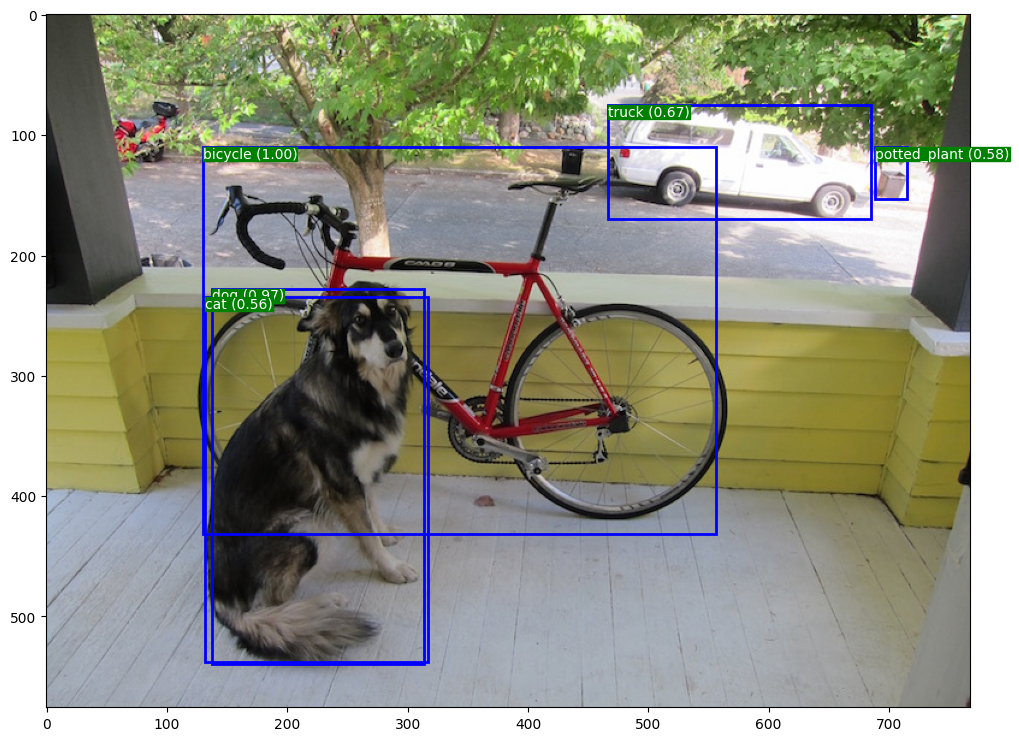

In [ ]:
import matplotlib.patches as patches
# Plot the bounding boxes on the image
plt.figure()
fig, ax = plt.subplots(1, figsize=(12,9))
ax.imshow(input_image)

# Walk over all bounding boxes found by the model
for c in range(len(scores)):
    # We pick a subset of labels based on confidence score
    if scores[c] < 0.5:
        continue

    base_index = c * 4
    y1, x1, y2, x2 = bboxes[base_index] * resized_height, bboxes[base_index + 1] * resized_width, bboxes[base_index + 2] * resized_height, bboxes[base_index + 3] * resized_width
    print(int(x1), int(y1), int(x2), int(y2), scores[c], category_index[labels[c]]['name'])
    color = 'blue'
    box_h = (y2 - y1)
    box_w = (x2 - x1)
    bbox = patches.Rectangle((x1, y1), box_w, box_h, linewidth=2, edgecolor=color, facecolor='none')
    ax.add_patch(bbox)
    label_text = "{} ({:0.2f})".format(category_index[labels[c]]['name'], scores[c])
    plt.text(x1, y1, s=label_text, color='white', verticalalignment='top', bbox={'color': "green", 'pad': 0})

# plt.axis('off')
plt.show()